In [1]:
%matplotlib widget
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import hilbert, butter, filtfilt, windows
from scipy.ndimage import uniform_filter1d

plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)

DATA_DIR = os.path.expanduser(
    "~/eedm_jml/daqAnalysisAndExperiments/MOT_fill/data"
)


def load_trace(fname=None, data_dir=DATA_DIR):
    """Load an npz trace. If fname is None, offer the most recent file."""
    if fname is None:
        files = sorted(glob.glob(os.path.join(data_dir, "*.npz")),
                       key=os.path.getmtime)
        if not files:
            raise FileNotFoundError(f"No .npz files in {data_dir}")
        fname = files[-1]
        ans = input(f"No file given. Load most recent?\n  {os.path.basename(fname)}\n[y/n] ")
        if ans.strip().lower() not in ("y", "yes", ""):
            raise RuntimeError("Aborted; pass fname explicitly.")
    elif not os.path.isabs(fname):
        fname = os.path.join(data_dir, fname)

    d = np.load(fname)
    times, volts = d["times"], d["voltages"]
    sr = float(d["sample_rate"])
    print(f"{os.path.basename(fname)}: {len(volts)/1e6:.3f} Mpts @ {sr/1e6:.3f} MSa/s, "
          f"{(times[-1]-times[0])*1e3:.2f} ms span")
    return times, volts, sr, fname

motFill_70dBGain_mirror_20260727_164647.npz: 1.000 Mpts @ 0.020 MSa/s, 49999.95 ms span


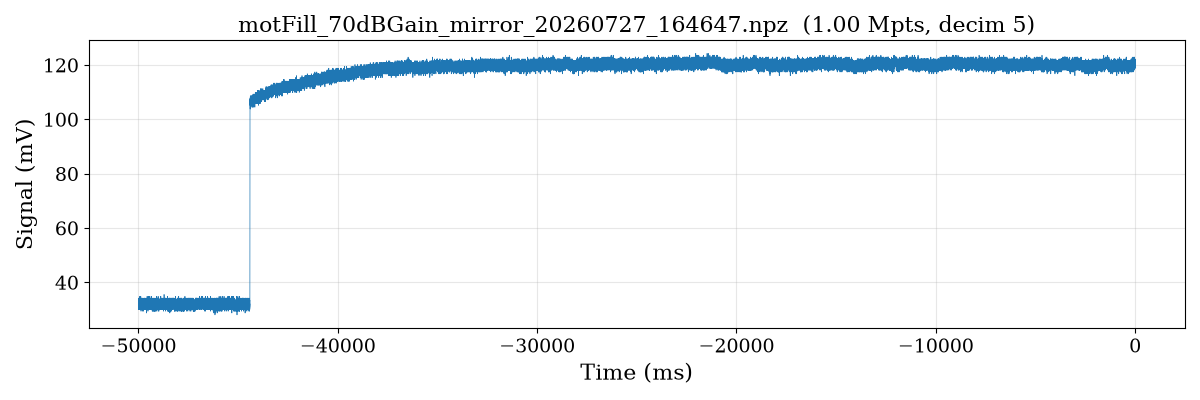

In [3]:
FNAME = None          # None -> prompt for most recent
MAX_PLOT_PTS = 200_000

times, voltages, sr, fname = load_trace(FNAME)

decim = max(1, len(voltages) // MAX_PLOT_PTS)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(times[::decim] * 1e3, voltages[::decim] * 1e3, lw=0.5)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Signal (mV)")
ax.set_title(f"{os.path.basename(fname)}  ({len(voltages)/1e6:.2f} Mpts, decim {decim})")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()